In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

Pada cell di atas, saya menggunakan library numpy untuk perhitungan matematis matriks citra, lalu matplotlib untuk menampilkan visual citra dan histogram, dan cv2 untuk membaca atau mengambil data dari sebuah citra

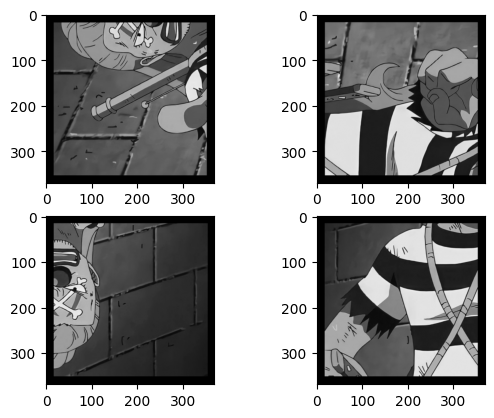

In [3]:
image1 = cv2.imread('assets/buggy1.png', cv2.COLOR_BGR2RGB)
image2 = cv2.imread('assets/buggy2.png', cv2.COLOR_BGR2RGB)
image3 = cv2.imread('assets/buggy3.png', cv2.COLOR_BGR2RGB)
image4 = cv2.imread('assets/buggy4.png', cv2.COLOR_BGR2RGB)

image1g = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
image2g = cv2.cvtColor(image2, cv2.COLOR_RGB2GRAY)
image3g = cv2.cvtColor(image3, cv2.COLOR_RGB2GRAY)
image4g = cv2.cvtColor(image4, cv2.COLOR_RGB2GRAY)


plt.subplot(2,2,1)
plt.imshow(image1g, cmap='gray')
plt.subplot(2,2,2)
plt.imshow(image2g, cmap='gray')
plt.subplot(2,2,3)
plt.imshow(image3g, cmap='gray')
plt.subplot(2,2,4)
plt.imshow(image4g, cmap='gray')

Pada cell di atas, saya melakukan pembacaan atau pengambilan data menggunakan cv2 untuk mengubah citra menjadi skala abu-abu atau grayscale

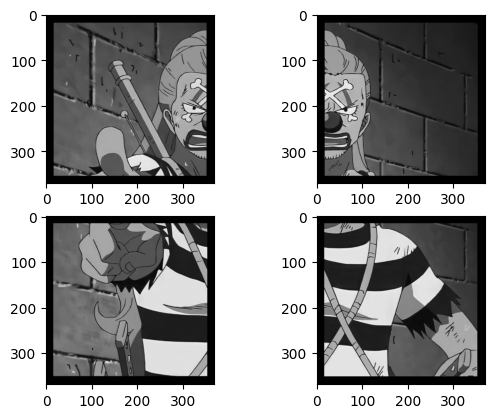

In [4]:
def rotate(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): 
                rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range(h):
            for j in range(w): 
                rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): 
                rot[w - 1 - j, i] = image[i, j]
        return rot
    
def flip(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

img2flip = flip(image3g, 'X')

plt.subplot(2,2,1)
img_rot1 = rotate(image1g, 90)
plt.imshow(img_rot1, cmap='gray')
plt.subplot(2,2,2)
img_rot2 = rotate(img2flip, 180)
plt.imshow(img_rot2, cmap='gray')
plt.subplot(2,2,3)
img_rot3 = rotate(image2g, 270)
plt.imshow(img_rot3, cmap='gray')
plt.subplot(2,2,4)
img_rot4 = flip(image4g, 'X')
plt.imshow(img_rot4, cmap='gray')

Pada cell di atas, saya melakukan rotasi dan flip pada citra-citra yang telah dibagi 4 bagian, untuk membuat visualnya pas atau cocok untuk digabungkan menjadi satu kesatuan. Saya melakukan rotasi untuk gambar 1 sebesar 90 derajat, gambar 2 di-flip terlebih dahulu terhadap sumbu X setelah itu dirotasi sebesar 180 derajat, gambar 3 dirotasi sebesar 270 derajat, dan gambar 4 di-flip terhadap sumbu X.

(369, 369)


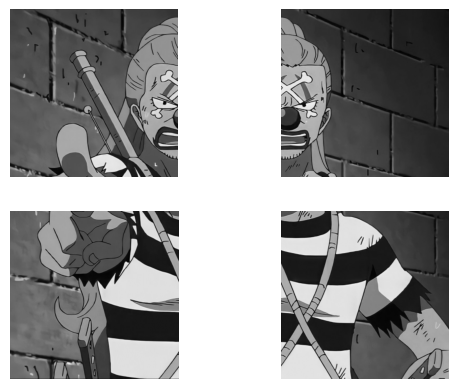

In [5]:
print(img_rot1.shape)
plt.subplot(2,2,1)
crop1 = img_rot1[17:352, 17:352]
plt.axis('off')
plt.imshow(crop1, cmap='gray')
plt.subplot(2,2,2)
crop2 = img_rot2[17:352, 17:352]
plt.axis('off')
plt.imshow(crop2, cmap='gray')
plt.subplot(2,2,3)
crop3 = img_rot3[17:352, 17:352]
plt.axis('off')
plt.imshow(crop3, cmap='gray')
plt.subplot(2,2,4)
crop4 = img_rot4[17:352, 17:352]
plt.axis('off')
plt.imshow(crop4, cmap='gray')


Pada cell di atas, saya melakukan crop atau pemotongan kepada masing masing gambar agar terlihat menyatu saat di-merge nanti, saya melakukannya dengan menentukan index yang ingin dipotong untuk masing masing gambar.

(335, 335)


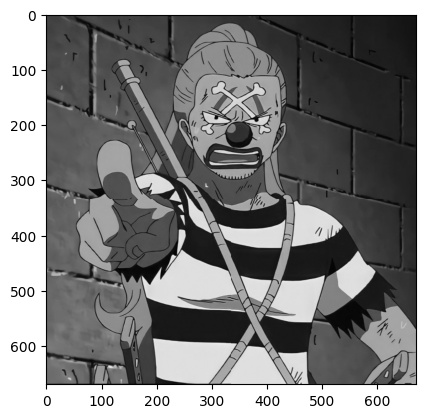

In [6]:
print(crop1.shape)
canvas = np.zeros((670, 670), dtype=np.uint8)
merge = np.zeros_like(canvas)
merge[0:335, 0:335] = crop1
merge[0:335, 335:670] = crop2
merge[335:670, 0:335] = crop3
merge[335:670, 335:670] = crop4
plt.imshow(merge, cmap='gray')

Pada cell di atas, saya melakukan penggabungan atau merge pada keempat gambar yang terpisah tadi. saya melakukannya dengan membuat canvas kosong baru dengan ukuran 670 x 670, yang kemudian diisi dengan keempat gambar tersebut berdasarkan letak index nya sehingga menjadi kesatuan.

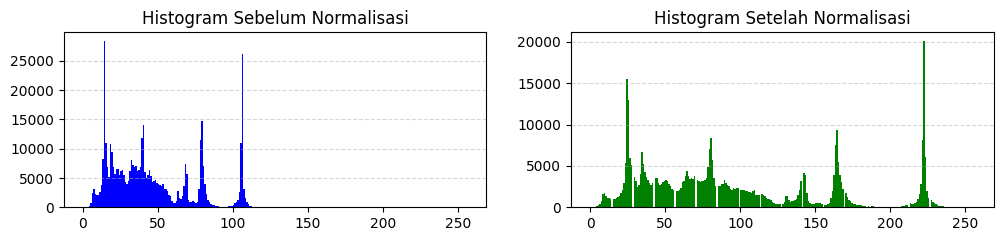

In [7]:
merge = merge.astype(np.float32) / 2.0

nilai_min = np.min(merge)
nilai_max = np.max(merge)

if nilai_max > nilai_min:
    citra_norm = ((merge - nilai_min) / (nilai_max - nilai_min)) * 255.0

    hasil_norm = citra_norm.astype(np.uint8)
else:
    hasil_norm = np.zeros_like(merge, dtype=np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
plt.hist(merge.ravel(), bins=256, range=[0, 256], color='blue')
plt.title('Histogram Sebelum Normalisasi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.subplot(2, 2, 2)
plt.hist(hasil_norm.ravel(), bins=256, range=[0, 256], color='green')
plt.title('Histogram Setelah Normalisasi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

Pada cell di atas, saya melakukan normalisasi pada gambar yang telah disatukan tersebut. Dapat dilihat pada histogram, sebelumnya penyebaran nilai piksel dari gambar tersebut tidak merata, lalu setelah dilakukan normalisasi terlihat penyebaran nilainya lebih merata.

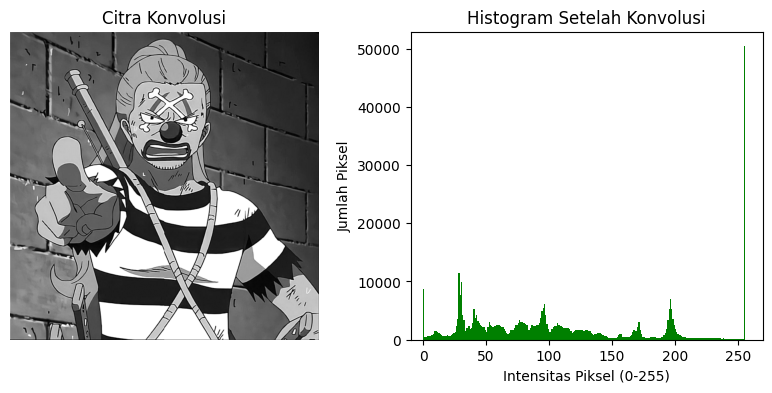

In [8]:
citra_float = hasil_norm.astype(np.float32)

kernel = np.array([
    [-0.1, -0.1, -0.1, -0.1],
    [-0.1,  0.6,  0.6, -0.1],
    [-0.1,  0.6,  0.6, -0.1],
    [-0.1, -0.1, -0.1, -0.1]
], dtype=np.float32)

citra_pad = np.pad(citra_float, pad_width=((1, 2), (1, 2)), mode='constant', constant_values=0)

tinggi, lebar = citra_float.shape
citra_konvolusi = np.zeros_like(citra_float)

for i in range(tinggi):
    for j in range(lebar):
        region = citra_pad[i:i+4, j:j+4]
        citra_konvolusi[i, j] = np.sum(region * kernel)

citra_clip = np.clip(citra_konvolusi, 0, 255)

citra_konvo = citra_clip.astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(citra_konvo, cmap='gray')
plt.title('Citra Konvolusi')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(citra_konvo.ravel(), bins=256, range=[0, 256], color='green')
plt.title('Histogram Setelah Konvolusi')
plt.xlabel('Intensitas Piksel (0-255)')
plt.ylabel('Jumlah Piksel')
plt.xlim([-10, 270])

plt.show()

Pada cell di atas, saya melakukan konvolusi pada gambar yang telah dinormalisasi dengan kernel:
    [-0.1, -0.1, -0.1, -0.1]
    [-0.1,  0.6,  0.6, -0.1]
    [-0.1,  0.6,  0.6, -0.1]
    [-0.1, -0.1, -0.1, -0.1]
Terlihat hasil visual dari konvolusi gambar tersebut menjadi lebih terang.